# **Demand Response on space heating of a single residential building using heat pump**

*This work addresses the optimal scheduling of residential heat pumps to balance thermal comfort, energy efficiency, and grid constraints using automatically generated mixed-integer linear programming models with reduced-order building thermal dynamics.*

### **Objective:**

*The primary objective is to compute optimal heat pump operation schedules that minimize electrical energy consumption while maintaining indoor thermal comfort and respecting grid constraints.*

*Two operational paradigms are considered:*

1. Uncoordinated operation, where each building independently minimizes its own energy consumption subject only to local comfort constraints.

2. Coordinated operation, where a centralized optimization minimizes aggregate energy use across all buildings while additionally enforcing system-level grid constraints on total energy and peak power demand.

## **Description of the datasets - building characteristics and Cambridge district description**

The methodology is demonstrated on the Cambridge residential district in Grenoble, France, which is heated using a combination of groundwater and electrical energy sources. The district consists of 16 externally insulated residential buildings with an average of 11 floors. All buildings were constructed after 2010 and comply with the French building energy regulation RT2012, achieving a 30% improved energy performance target, corresponding to a primary energy consumption of approximately 50 kWh·m⁻²·year⁻¹. A simplified representation of the district is shown in the figure below.

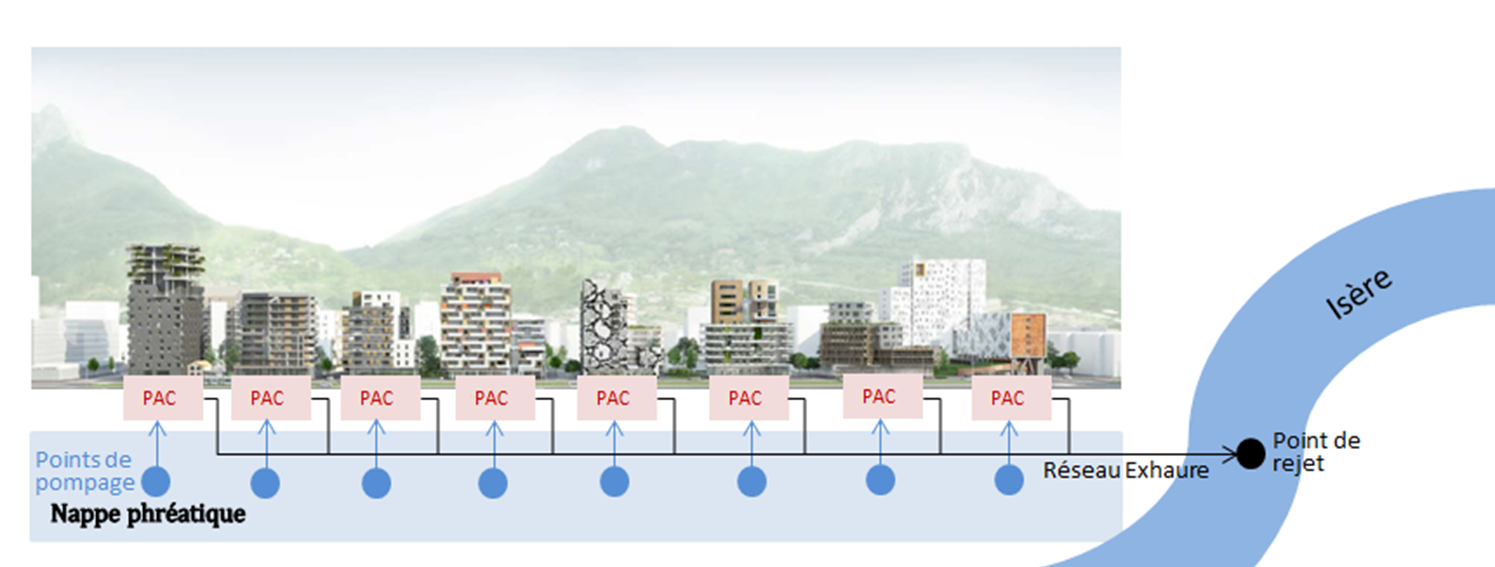

More details on geometric and physical parameters are given further in the table below.

**District main input parameter statistics of the buildings**

| Parameter                     | Mean Value | Standard Deviation |
|-------------------------------|------------|--------------------|
| Footprint / Roof area (m²)    | 322.6      | 119.7              |
| Windows area (m²)             | 623.0      | 343.6              |
| External walls area (m²)      | 1875.9     | 993.0              |
| U basement (W·m⁻²·K⁻¹)        | 0.76       | No variation       |
| U roof (W·m⁻²·K⁻¹)            | 0.17       | 0.025              |
| U windows (W·m⁻²·K⁻¹)         | 1.61       | 0.31               |
| U external walls (W·m⁻²·K⁻¹)  | 0.43       | 0.18               |
| Walls emissivity              | 0.90       | No variation       |
| Roof emissivity               | 0.94       | No variation       |
| Windows emissivity            | 0.89       | No variation       |
| Walls absorptivity            | 0.50       | No variation       |
| Roof absorptivity             | 0.60       | No variation       |
| Windows transmissivity        | 1.00       | No variation       |
| Number of floors              | 10.56      | 3.01               |


## **Omegalpes and Thermal modeling**

*This notebook has been developed with OMEGAlpes version 0.5.0. It is shared with the licence [Apache 2.0](https://www.apache.org/licenses/LICENSE-2.0.html), Copyright 2025 G2Elab / MAGE*,

First time using a Jupyter Notebook ? 

> You can then easily use this Jupyter notebook by runnning each cell with the Run (\"Exécuter\" in French) icon in the toolbar on top of the page. When the orange notebook icon in the tab turns into an hourglass, this means the code is still running.
    
*This notebook has been developed with OMEGAlpes version 0.5.0.*

- This notebook addresses the topic of the electrical flexibility on the demand-side, by focusing on the residential buildings.
- Specifically, it aims to quickly formulate the optimal operation of building heat pumps, according to environmental or grid issues. 
- Indeed the literature shows many examples of quantification of the flexibility impacts, but mostly relying on pre-defined strategies. 
- To go from the evaluation of some strategies to the formulation of the optimal planning, we are introducing a methodology based on the automatic generation of models dedicated to optimization. 


Here is a representation of the energy system following OMEGAlpes graphical representation

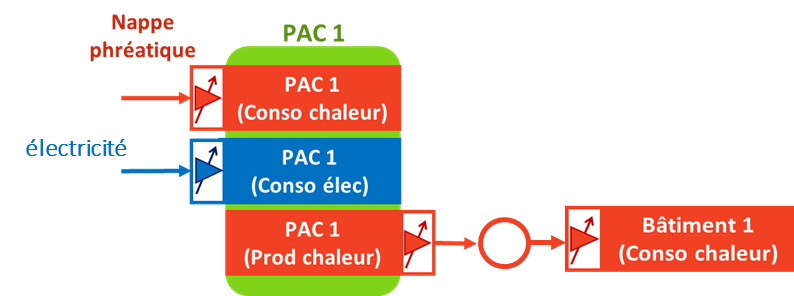

### **Building Thermal Model – Parameters and Inputs**

The building thermal model relies on the following inputs and parameters:

1. **Weather data**  
   External climatic conditions, provided via the `weather_file.csv` file.

2. **Usage profiles**  
   Internal gains due to occupancy, appliances, and lighting, provided via the `internal_gains.csv` file.

3. **Comfort criteria**  
   Thermal comfort requirements, defined through indoor temperature setpoints and allowable comfort bands.

4. **Building characteristics**  
   Parameters used to construct the building thermal dynamic model, including:


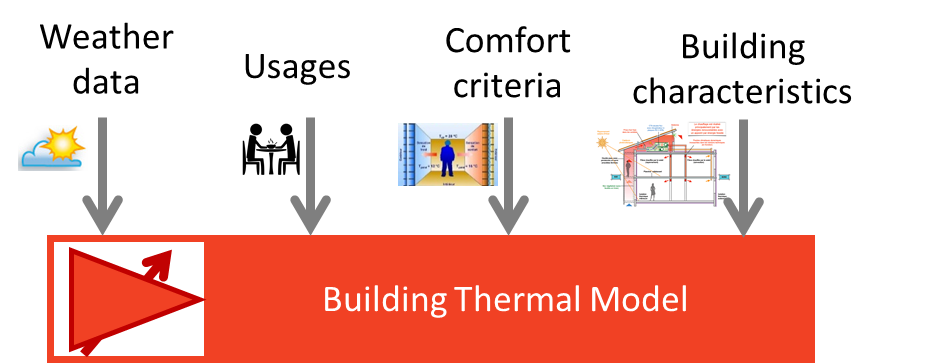


Detailed thermal-dynamics models require extensive data and are computationally heavy for optimizing heat-pump operation. Reduced-order models are therefore preferred, as long as they capture the building’s response to demand-side management.

A low-order RC network model (SIA 2044) meets these needs because its linear structure fits well within MILP frameworks. The model below follows the SIA 2044 standard and is adapted from the City Energy Analyst (CEA) framework developed at ETH Zurich.

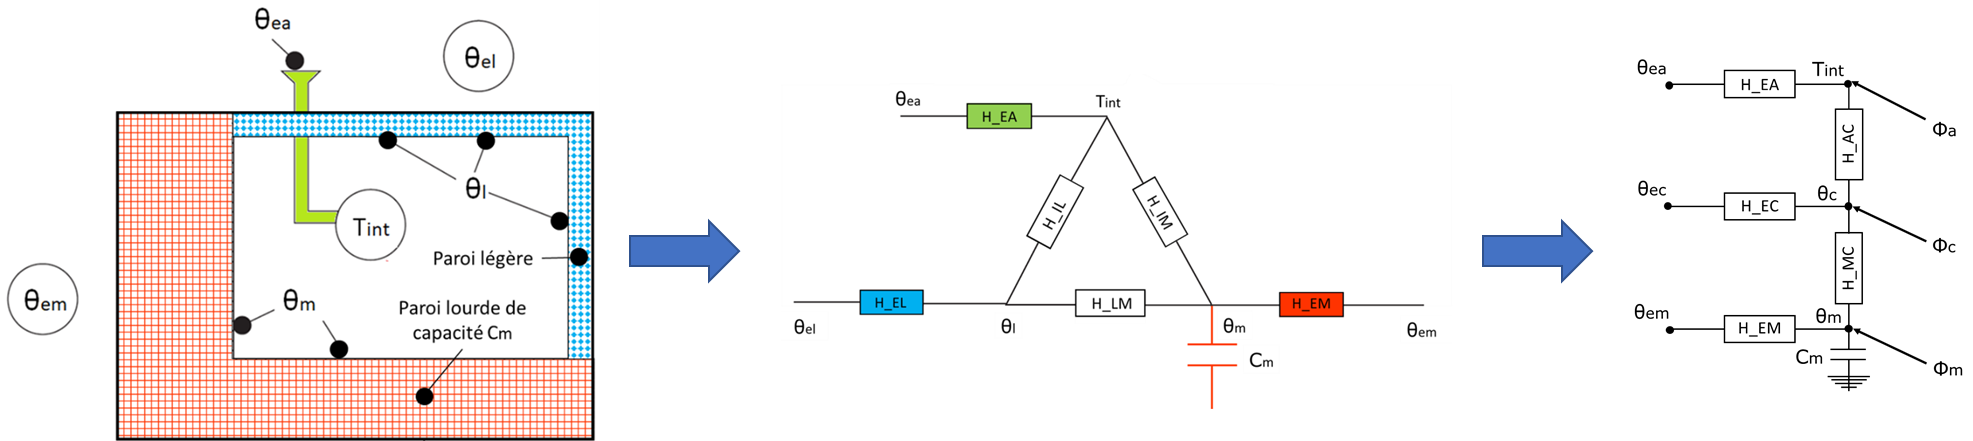

For OMEGAlpes building models, we need the following data:

  - U-values and surface areas of ground floors, roofs, external walls, and windows  
  - Absorptivity and emissivity of walls, roofs, and windows  
  - Window transmittance  
  - Surface areas  
  - Net leased area  
  - Number of floors  
  - Building height  
  - Building type (light, medium, or heavy)

  
Comprehensive descriptions of the modeling approach and the relevant mathematical equations are provided in the following references:

*[1] Pajot, C., Delinchant, B., Maréchal, Y., & Frésier, D. (2025). Impact of Heat Pump Flexibility in a French Residential Eco-District. Buildings, 8(10), 145. https://doi.org/10.3390/buildings8100145*

*[2] Pajot, C., Artiges, N., Delinchant, B., & Maréchal, Y. (2019, September). Building Reduced Model for MILP Optimization: Application to Demand Response of Residential Buildings. In Building Simulation Conference 2019.*



**Operating steps:**

1. importing the relevant libraries and python source files
2. Creating the unit dedicated to time management
3. Importing building specification parameters from data files
4. Creating the building heat load
5. Creating the heat node for the energy flows - for coordinated optimal control
6. Connecting units to the nodes - for coordinated optimal control
7. Adding all nodes (and connected units) to the optimization model
8. Adding the preferred objectives to the optimization model
9. Writing into lp file
10. Running optimization and update values
11. Display using preferred plotting tool or plot methods defined in OMEGAlpes



**Importing relevant libraries**

In [ ]:
import sys
sys.path.append('..')
import main_cambridge
from omegalpes.general.optimisation.model import OptimisationModel
from omegalpes.energy.energy_nodes import EnergyNode
from omegalpes.energy.units.production_units import VariableProductionUnit
from omegalpes.energy.energy_types import elec
from omegalpes.general.utils.output_data import save_energy_flows
import pandas as pd
from pulp import GUROBI_CMD

**Creating the unit dedicated to time management and Impotying building related parameters as dataframe**

In [ ]:
from omegalpes.general.time import TimeUnit
start = '01/01/2025 00:00'
end = '03/01/2025 23:50' # information should be from the input files
t_ind = 144*3 # this is determined based on the time steps and number of days for simulation study
time = TimeUnit(start = start , periods = t_ind, dt = 1/6)
time_index = pd.date_range(start=start, periods=t_ind, freq='10min')
bld_df = pd.read_csv('../Cas_Cambridge/data/bld_param.csv', delimiter=';')
temp_df = pd.read_csv('../Cas_Cambridge/data/csv_temperature.csv')
weather_df = pd.read_csv('../Cas_Cambridge/data/weather_data.csv')
SAVE_PATH = "C:\\Users\\caby\\Documents\\Analyse IBPSA\\sans_pv\\charge_fixe\\10_min\\"


In [ ]:
import math
temperature_df = pd.DataFrame()
temperature_df['time'] = temp_df['time']
for k in range(len(bld_df)):
    name = bld_df.at[k,'Name']
    T_set = temp_df[name].fillna(method='ffill').astype(float)
    temperature_df[name] = T_set
    


In [ ]:
import plotly.express as px

temperature_df["time"] = pd.to_datetime(temperature_df["time"])

fig = px.line(
    temperature_df,
    x="time",
    y=["CI4", "CE2", "CJ1", "CL1", "CI3"],
    title="Temperature vs Time"
)
fig.write_html(SAVE_PATH + "temperature.html")
fig.show()

In [ ]:
import plotly.express as px

weather_df["TIMESTAMP"] = pd.to_datetime(weather_df["TIMESTAMP"])

fig = px.line(
    weather_df,
    x="TIMESTAMP",
    y=["AirTemp_Avg", "Ray_Global_RSR2_Avg", "Ray_Direct_RSR2_Avg"],
    title="Temperature vs Time"
)

fig.write_html(SAVE_PATH + "temperature_ray.html")

fig.show()

**Extract buikding name to use later for individual building analysis**

In [ ]:
building_codes = bld_df['Name'].tolist()
# Map building code → index
index_to_building = {idx: code for idx, code in enumerate(building_codes)}

# Show
print(index_to_building)


## **Create an uncoordinated scheduling of heat pumps**

**Operating steps:**

1. Creating the building heat load by importing building specification parameters from data files
2. Create an empty optimization model.
3. Adding all nodes (and connected units) to the optimization model
4. Adding the preferred objectives to the optimization model (which is done internally inside create_reference_scenario)
5. Writing into lp file
6. Running optimization and update and store values
7. Display using preferred plotting tool or plot methods defined in OMEGAlpes

*Note: create_scenario_reference(time, bld_df, T_set, t_marg) is invoked to build a model that captures the building’s heating load and heat-pump behavior, with the sole objective of minimizing peak energy consumption while maintaining the thermal comfort.*

Illustrative example for one building 

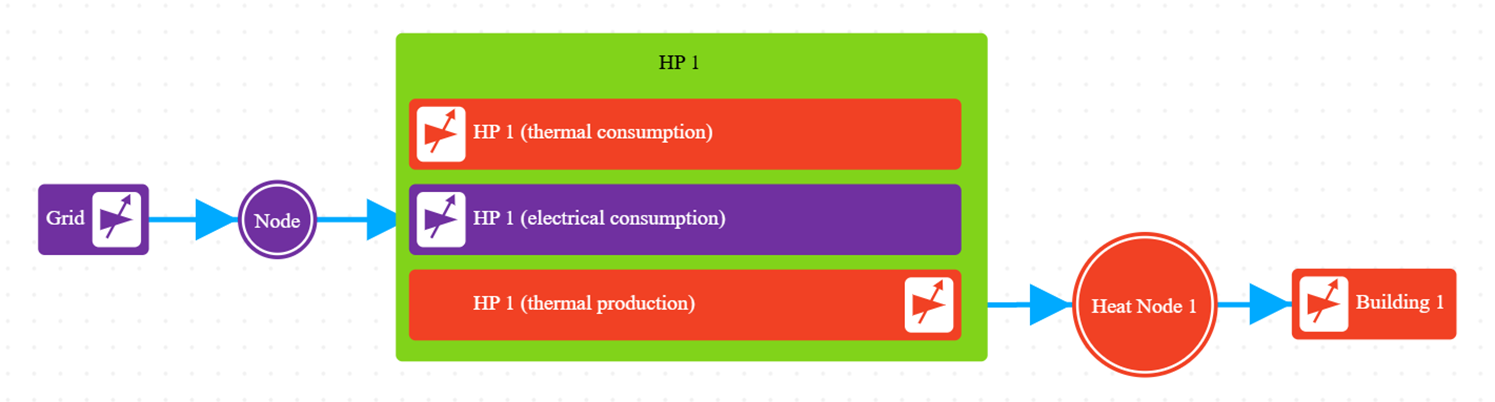

In [ ]:
bld_heat_nodes, bld_elec_units = main_cambridge.create_scenario_reference(time, bld_df[0:1],
                                                               T_set=21,t_marg=1)

model = OptimisationModel(time, name='Cambridge_opt_model_uncoordinated', verbose=True)
grid_prod = VariableProductionUnit(time = time , name = "grid_prod", p_max=100000, energy_type='Electrical',)
node = EnergyNode(time = time,  name = 'node1', energy_type=elec)
#grid_prod.minimize_production(weight=1)
node.connect_units(grid_prod,*bld_elec_units )
model.add_nodes(*bld_heat_nodes, node)
model.writeLP('{}.lp'.format(model.name))
model.solve_and_update(GUROBI_CMD(options=[('NumericFocus', 3),
                                            ('MIPGap', 0.005)]))



In [ ]:
save_energy_flows(*bld_heat_nodes,
                    file_name='results/cambridge_uncoordinated_scenario_results')
save_energy_flows(node,
                    file_name='results/cambridge_uncoordinated_scenario_results_elec_profiles')
main_cambridge.save_hp_elec(*bld_heat_nodes,
                      file_name='results/cambridge_uncoordinated_scenario_results_electrical')

main_cambridge.save_phi_s(*bld_heat_nodes,
            file_name='results/cambridge_uncoordinated_scenario_results_phi_s')

main_cambridge.save_Top(*bld_heat_nodes,
            file_name='results/cambridge_uncoordinated_scenario_results_top')

**Display - Uncoordinated thermal production and temperature from building CI4**

*remark : building demand and heat pump production are equal*

In [ ]:
import pandas as pd
import plotly.express as px
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

uncoordinated_df = pd.read_csv("results/cambridge_uncoordinated_scenario_results.csv", sep="\t")
uncoordinated_df_top = pd.read_csv("results/cambridge_uncoordinated_scenario_results_top.csv", sep="\t")
temperature_df["time"] = pd.to_datetime(temperature_df["time"])

# Filter same date range (IMPORTANT to match axes)
mask = (
    (temperature_df["time"] >= "2025-01-03") &
    (temperature_df["time"] <= "2025-01-31")
)
temp_filtered = temperature_df.loc[mask]
mask = (
    (weather_df["TIMESTAMP"] >= "2025-01-03") &
    (weather_df["TIMESTAMP"] <= "2025-01-31")
)
weather_filtered = weather_df.loc[mask]

main_cambridge.plot_hp_production_vs_temperature_building(
    uncoordinated_df,
    uncoordinated_df_top,
    building_code=index_to_building[0],
    building_index=0,
    start_date="2025-01-03",
    end_date="2025-01-31",
    scenario = 'uncoordinated'
)


# Create temperature trace
temp_fig = px.line(
    temp_filtered,
    x="time",
    y="CI4"
)
fig.write_html(SAVE_PATH + "temperature_ci4.html")
temp_fig.show()

import plotly.express as px

fig = px.line(
    weather_filtered,
    x="TIMESTAMP",
    y="AirTemp_Avg",
    title="Temperature vs Time"
)

fig.show()

fig = px.line(
    weather_filtered,
    x="TIMESTAMP",
    y="Ray_Direct_RSR2_Avg",
    title="Temperature vs Time"
)

fig.show()


**Uncoordinated electrical consumption by all buildings**

In [ ]:
uncoordinated_df = pd.read_csv("results/cambridge_uncoordinated_scenario_results_electrical.csv", sep="\t")
main_cambridge.plot_hp_electrical_consumption(
    uncoordinated_df,
    start_date="2025-01-03",
    end_date="2025-01-31",
    title="HP electrical consumption - coordinated - all buildings"
)

**total electricity consumption - uncoordinated**


In [ ]:

uncoordinated_df = pd.read_csv(
    "results/cambridge_uncoordinated_scenario_results_electrical.csv", sep="\t"
)

main_cambridge.plot_total_hp_electrical_consumption(
    uncoordinated_df,
    start_date="2025-01-03",
    end_date="2025-01-31",
    title="HP electrical consumption - uncoordinated - all buildings"
)

## **Create an coordinated scheduling of heat pumps**
create_flex_scenario_without_lncmi(time, bld_df, obj='CO2',T_set=21,t_marg=1) is invoked to build a model that captures the building’s heating load and heat-pump behavior, with the objective of minimizing peak electricty consumption while maintaining the thermal comfort.

An illustrative example with two buildings are demonstrated below.

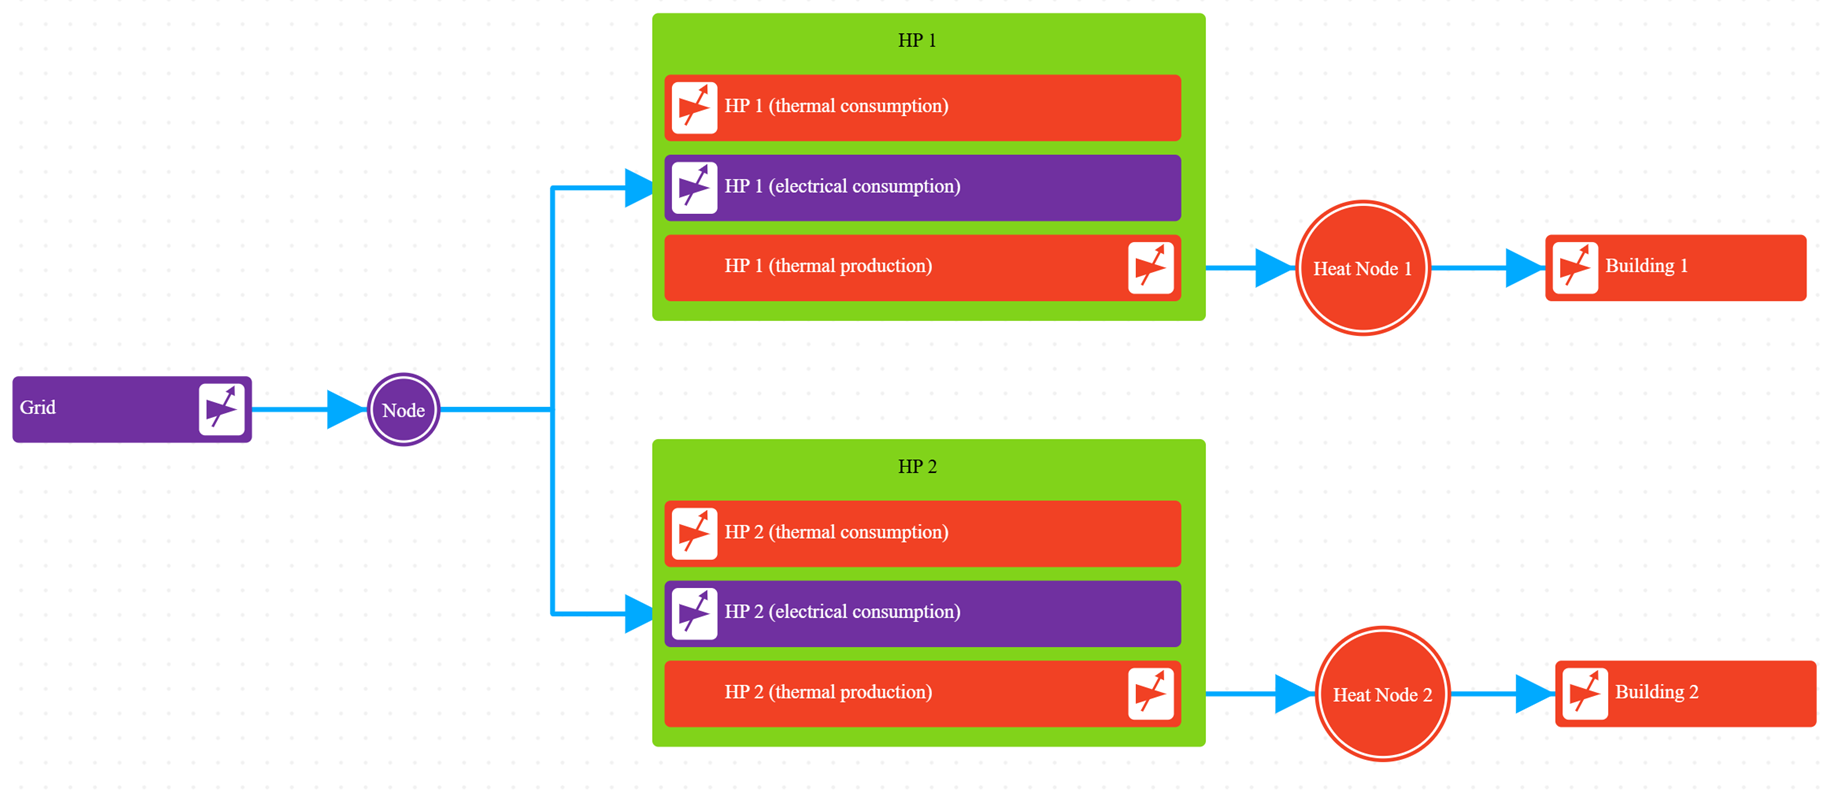

In [ ]:

bld_heat_nodes, bld_elec_units = main_cambridge.create_flex_scenario_without_lncmi(time, bld_df[0:1], obj='CO2',
                                                        T_set=21,
                                                        t_marg=1)

model = OptimisationModel(time, name='Cambridge_opt_model_coordinated', verbose=False)
grid_prod = VariableProductionUnit(time = time , name = "grid_prod", p_max=18.87, energy_type='Electrical',)
node = EnergyNode(time = time,  name = 'node1', energy_type=elec)
grid_prod.minimize_production(weight=1)
node.connect_units(grid_prod,*bld_elec_units )
model.add_nodes(*bld_heat_nodes, node)
model.writeLP('{}.lp'.format(model.name))

model.solve_and_update(GUROBI_CMD(options=[('NumericFocus', 3),
                                            ('MIPGap', 0.005)]), find_infeasible_cst_set=True)
save_energy_flows(*bld_heat_nodes,
                      file_name='results/cambridge_coordinated_scenario_results')
save_energy_flows(node,
                    file_name='results/cambridge_coordinated_scenario_results_elec_profiles')

main_cambridge.save_hp_elec(*bld_heat_nodes,
                      file_name='results/cambridge_coordinated_scenario_results_electrical')

main_cambridge.save_Top(*bld_heat_nodes,
             file_name='results/cambridge_coordinated_scenario_results_top')

main_cambridge.save_phi_s(*bld_heat_nodes,
             file_name='results/cambridge_coordinated_scenario_results_phi_s')

### **Coordinated - one building demand (thermal consumption) with internal temperature**
**Display of thermal production and temperature for building CI4**

*remark : building demand and heat pump production are equal*

In [ ]:
import pandas as pd
import plotly.express as px
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

coordinated_df = pd.read_csv("results/cambridge_coordinated_scenario_results.csv", sep="\t")
coordinated_df_top = pd.read_csv("results/cambridge_coordinated_scenario_results_top.csv", sep="\t")
start_date, end_date = "2025-01-03", "2025-01-31"

main_cambridge.plot_hp_production_vs_temperature_building(
    coordinated_df,
    coordinated_df_top,
    building_code=index_to_building[0],
    building_index=0,
    start_date="2025-01-03",
    end_date="2025-01-31", 
    scenario = 'coordinated'
)

In [ ]:
coordinated_df = pd.read_csv("results/cambridge_coordinated_scenario_results_electrical.csv", sep="\t")

main_cambridge.plot_hp_electrical_consumption(
    coordinated_df,
    start_date="2025-01-03",
    end_date="2025-01-31",
    title="HP electrical consumption - coordinated - all buildings"
)

**total electricity consumption - coordinated**

In [ ]:
coordinated_df = pd.read_csv("results/cambridge_coordinated_scenario_results_electrical.csv", sep="\t")

main_cambridge.plot_total_hp_electrical_consumption(
    coordinated_df,
    start_date="2025-01-03",
    end_date="2025-01-31",
    title="HP electrical consumption - coordinated - all buildings"
)


### **Display and Comparison**

**total electrical consumption**

In [ ]:
coordinated_df = pd.read_csv(
    "results/cambridge_coordinated_scenario_results_electrical.csv", sep="\t"
)
uncoordinated_df = pd.read_csv(
    "results/cambridge_uncoordinated_scenario_results_electrical.csv", sep="\t"
)

main_cambridge.plot_total_hp_electrical_consumption_comparison(
    coordinated_df,
    uncoordinated_df,
    start_date="2025-01-03",
    end_date="2025-01-31"
)



import plotly.express as px

fig = px.line(
    weather_filtered,
    x="TIMESTAMP",
    y="AirTemp_Avg",
    title="Temperature vs Time"
)

fig.show()

fig = px.line(
    weather_filtered,
    x="TIMESTAMP",
    y="Ray_Direct_RSR2_Avg",
    title="Ray_Direct_RSR2_Avg vs Time"
)

fig.show()

**Comparison of operative temperature for the building CI4**

In [ ]:
coordinated_df_top = pd.read_csv(
    "results/cambridge_coordinated_scenario_results_top.csv", sep="\t"
)
uncoordinated_df_top = pd.read_csv(
    "results/cambridge_uncoordinated_scenario_results_top.csv", sep="\t"
)

main_cambridge.plot_operative_temperature_comparison_building( 
    coordinated_df_top,
    uncoordinated_df_top,
    building_code = index_to_building[0],
    building_index=0,
    start_date="2025-01-03",
    end_date="2025-01-31"
)



**Comparison of HP production for the building CI4**

In [ ]:
# Merge data
coordinated_df = pd.read_csv("results/cambridge_coordinated_scenario_results.csv", sep="\t")
uncoordinated_df = pd.read_csv("results/cambridge_uncoordinated_scenario_results.csv", sep="\t")

main_cambridge.plot_hp_production_comparison_building(
    coordinated_df,
    uncoordinated_df,
    building_code = index_to_building[0],
    building_index=0,
    start_date="2025-01-03",
    end_date="2025-01-31"
)


### **Key Performance Indices (KPIs)**

- **Peak-to-Average Ratio (PAR):**  
  The ratio of the maximum (peak) electrical consumption to the average electrical consumption over a period. A higher PAR indicates more pronounced peaks relative to typical load, highlighting potential stress on the system.

- **Maximum Power Demand:**  
  The highest electrical consumption recorded during the period. This metric indicates the peak load that the system must be able to support.

- **Average Power Consumption:**  
  The mean electrical consumption over the period. This metric reflects the typical operational load and overall energy usage.

In [ ]:
coordinated_df = pd.read_csv("results/cambridge_coordinated_scenario_results_electrical.csv", sep="\t")
uncoordinated_df = pd.read_csv("results/cambridge_uncoordinated_scenario_results_electrical.csv", sep="\t")

merged_df = main_cambridge.prepare_elec_consumption_comparison(
    coordinated_df,
    uncoordinated_df,
    start_date="2025-01-03",
    end_date="2025-01-31"
)
